In [2]:
import os
import glob
from pathlib import Path
from dotenv import load_dotenv

from langchain_community.document_loaders import TextLoader, PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# Cargar la API key de Groq desde .env
load_dotenv("../.env")
assert os.getenv("GROQ_API_KEY"), "No se encontró GROQ_API_KEY en .env"
print("API key cargada ✓")

API key cargada ✓


In [3]:
# Encuentra todos los archivos del corpus
ruta_corpus = Path("../rag/corpus")

archivos_md = list(ruta_corpus.rglob("*.md"))
archivos_pdf = list(ruta_corpus.rglob("*.pdf"))

print(f"Archivos .md encontrados: {len(archivos_md)}")
for f in archivos_md:
    print(f"  - {f.relative_to(ruta_corpus)}")

print(f"\nArchivos .pdf encontrados: {len(archivos_pdf)}")
for f in archivos_pdf:
    print(f"  - {f.relative_to(ruta_corpus)}")

Archivos .md encontrados: 12
  - 01_cinco_c_credito.md
  - 02_credit_scoring.md
  - 06_metricas_evaluacion.md
  - 10_data_leakage.md
  - 03_pd_lgd_ead_basilea.md
  - 08_random_forest_scoring.md
  - 04_variables_german_credit.md
  - 11_validacion_cruzada.md
  - 07_regresion_logistica_scoring.md
  - 12_sarc_colombia.md
  - 05_desbalance_clases.md
  - 09_encoding_categoricas.md

Archivos .pdf encontrados: 2
  - bcbs128_credit_risk.pdf
  - 20230817_capitulo_ii.pdf


In [4]:
documentos = []

# Cargar markdowns
for archivo in archivos_md:
    loader = TextLoader(str(archivo), encoding="utf-8")
    docs = loader.load()
    # Añadir metadata con la fuente
    for d in docs:
        d.metadata["fuente"] = archivo.name
        d.metadata["tipo"] = "corpus_generado"
    documentos.extend(docs)

# Cargar PDFs
for archivo in archivos_pdf:
    print(f"Cargando {archivo.name}... ", end="", flush=True)
    loader = PyPDFLoader(str(archivo))
    docs = loader.load()  # devuelve una lista, una entrada por página
    for d in docs:
        d.metadata["fuente"] = archivo.name
        d.metadata["tipo"] = "pdf_oficial"
    documentos.extend(docs)
    print(f"{len(docs)} páginas")

print(f"\nTotal de documentos cargados: {len(documentos)}")

Cargando bcbs128_credit_risk.pdf... 68 páginas
Cargando 20230817_capitulo_ii.pdf... 44 páginas

Total de documentos cargados: 124


In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = splitter.split_documents(documentos)
print(f"Total de chunks: {len(chunks)}")
print(f"\nEjemplo de chunk:")
print(f"Fuente: {chunks[0].metadata['fuente']}")
print(f"Contenido (primeros 300 chars):\n{chunks[0].page_content[:300]}")

Total de chunks: 463

Ejemplo de chunk:
Fuente: 01_cinco_c_credito.md
Contenido (primeros 300 chars):
# Las 5C del crédito

Las 5C del crédito son el marco tradicional que utilizan las entidades financieras para evaluar el riesgo crediticio de un solicitante. Son: carácter, capacidad, capital, colateral y condiciones.

**Carácter** se refiere a la historia y disposición del solicitante para cumplir 


In [6]:
print("Cargando modelo de embeddings (primera vez descarga ~120MB)...")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

# Test rápido
vec_prueba = embeddings.embed_query("¿Qué es el credit scoring?")
print(f"Modelo cargado ✓")
print(f"Dimensión de los embeddings: {len(vec_prueba)}")

Cargando modelo de embeddings (primera vez descarga ~120MB)...


/tmp/ipykernel_28595/3971720775.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Modelo cargado ✓
Dimensión de los embeddings: 384


In [7]:
ruta_chroma = "../rag/chroma_db"

# Si ya existía de una corrida anterior, lo borramos para empezar limpio
import shutil
if os.path.exists(ruta_chroma):
    shutil.rmtree(ruta_chroma)
    print("Vector store anterior eliminado.")

print(f"Indexando {len(chunks)} chunks en ChromaDB...")
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=ruta_chroma,
    collection_name="credit_scoring"
)
print(f"Vector store creado ✓")
print(f"Total documentos indexados: {vectorstore._collection.count()}")

Vector store anterior eliminado.
Indexando 463 chunks en ChromaDB...


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vector store creado ✓
Total documentos indexados: 463


In [8]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 8} 
)

def probar_retriever(pregunta):
    print(f"\n{'='*70}")
    print(f"Pregunta: {pregunta}")
    print(f"{'='*70}")
    
    docs = retriever.invoke(pregunta)
    for i, doc in enumerate(docs, 1):
        print(f"\n--- Chunk {i} (fuente: {doc.metadata.get('fuente', 'N/A')}) ---")
        print(doc.page_content[:400])
        if len(doc.page_content) > 400:
            print("...")

# Tres preguntas de prueba: una sobre el dataset, una sobre teoría, una sobre regulación
probar_retriever("¿Qué significa la variable estado_cuenta en el dataset?")
probar_retriever("¿Qué es la probabilidad de incumplimiento PD en Basilea?")
probar_retriever("¿Qué exige el SARC sobre los modelos de credit scoring?")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Pregunta: ¿Qué significa la variable estado_cuenta en el dataset?

--- Chunk 1 (fuente: 10_data_leakage.md) ---
**Fuga por features futuras.** Usar variables que en el momento de la decisión real no estarían disponibles. Por ejemplo, incluir "número de pagos realizados" para predecir incumplimiento es trampa: esa información solo existe después de haber otorgado el crédito.

**Fuga por estratificación de variables relacionadas con el target.** Si se balancean los datos antes del split, ambos conjuntos compa
...

--- Chunk 2 (fuente: 09_encoding_categoricas.md) ---
# Encoding de variables categóricas en modelos de credit scoring

Los algoritmos de machine learning requieren entradas numéricas. Las variables categóricas como `proposito` del crédito o `estado_cuenta` deben convertirse a representaciones numéricas antes del entrenamiento. La elección de la técnica de encoding tiene impacto directo en el rendimiento del modelo.

**One-Hot Encoding** crea una col
...

--- Chunk 3 (fuente: 0

In [15]:
from langchain_ollama import ChatOllama

# LLM para el RAG productivo (responder preguntas del usuario)
rag_llm = ChatOllama(
    model="llama3.1:8b",
    temperature=0.1,        # bajo = fiel al contexto, no creativo
    num_predict=600,        # equivalente al max_tokens=600 que tenías con Groq
    base_url="http://localhost:11434",
)

# Test rápido
test = rag_llm.invoke("Responde solo con 'OK' si me lees.")
print(f"Ollama responde: {test.content}")

Ollama responde: OK


In [16]:
PROMPT_TEMPLATE = """Eres un asistente experto en credit scoring y gestión de riesgo crediticio. Tu tarea es responder preguntas usando ÚNICAMENTE la información del contexto proporcionado.

Reglas estrictas:
1. Si la respuesta está en el contexto, respóndela de forma clara y concisa, en español.
2. Si la información no está en el contexto, di explícitamente: "No tengo información suficiente en el corpus para responder eso."
3. NO inventes datos, cifras ni referencias normativas que no estén en el contexto.
4. Cuando uses información del contexto, cita la fuente entre paréntesis al final de cada afirmación importante. Ejemplo: (fuente: 03_pd_lgd_ead_basilea.md)
5. Si el contexto tiene información contradictoria, menciónalo.

Contexto:
{contexto}

Pregunta: {pregunta}

Respuesta:"""


def responder(pregunta, k=8, verbose=False):
    # 1. Retrieval
    docs = vectorstore.similarity_search(pregunta, k=k)
    
    # 2. Armar el contexto con marcadores de fuente
    contexto = "\n\n---\n\n".join([
        f"[fuente: {d.metadata.get('fuente', 'desconocida')}]\n{d.page_content}"
        for d in docs
    ])
    
    if verbose:
        print(f"--- Chunks recuperados ({len(docs)}) ---")
        for i, d in enumerate(docs, 1):
            print(f"{i}. {d.metadata.get('fuente', 'N/A')}")
        print()
    
    # 3. Construir el prompt y llamar a Ollama via LangChain
    prompt = PROMPT_TEMPLATE.format(contexto=contexto, pregunta=pregunta)
    
    # LangChain usa formato de mensajes diferente al cliente de Groq
    messages = [
        ("system", "Eres un asistente experto que responde con precisión usando solo la información proporcionada."),
        ("human", prompt),
    ]
    
    response = rag_llm.invoke(messages)
    respuesta = response.content
    
    fuentes = list({d.metadata.get("fuente", "N/A") for d in docs})
    
    return {
        "pregunta": pregunta,
        "respuesta": respuesta,
        "fuentes": fuentes,
        "chunks_usados": len(docs),
    }

In [17]:
preguntas_prueba = [
    # Pregunta del dominio del dataset
    "¿Qué significa la variable estado_cuenta en el dataset German Credit y por qué es predictiva?",
    
    # Pregunta sobre teoría/Basilea
    "¿Qué son PD, LGD y EAD según el enfoque IRB de Basilea II?",
    
    # Pregunta sobre regulación colombiana
    "¿Qué exige el SARC sobre los procesos de otorgamiento de crédito?",
    
    # Pregunta sobre metodología ML
    "¿Por qué la métrica accuracy no es adecuada para credit scoring con clases desbalanceadas?",
    
    # Pregunta que debería decir "no sé" (fuera del corpus)
    "¿Cuál es el precio actual del dólar en Colombia?",
]

for p in preguntas_prueba:
    resultado = responder(p, verbose=False)
    print(f"\n{'='*70}")
    print(f"P: {resultado['pregunta']}")
    print(f"{'='*70}")
    print(f"R: {resultado['respuesta']}")
    print(f"\nFuentes consultadas: {resultado['fuentes']}")


P: ¿Qué significa la variable estado_cuenta en el dataset German Credit y por qué es predictiva?
R: La variable **estado_cuenta** (A11-A14) en el dataset German Credit se refiere al estado de la cuenta corriente del solicitante. Es la variable más predictiva del dataset (fuente: 04_variables_german_credit.md). A11 indica saldo negativo (mayor riesgo), A12 saldo entre 0 y 200 DM, A13 saldo mayor a 200 DM, y A14 indica que el solicitante no tiene cuenta corriente registrada. Paradójicamente, A14 tiene menor tasa de incumplimiento que A11 (fuente: 04_variables_german_credit.md).

Fuentes consultadas: ['05_desbalance_clases.md', '10_data_leakage.md', '08_random_forest_scoring.md', '03_pd_lgd_ead_basilea.md', '01_cinco_c_credito.md', '07_regresion_logistica_scoring.md', '04_variables_german_credit.md']

P: ¿Qué son PD, LGD y EAD según el enfoque IRB de Basilea II?
R: Según el enfoque IRB de Basilea II, PD (Probability of Default) es la probabilidad de incumplimiento del deudor en un horizo

In [18]:
"""
Dataset de evaluación del sistema RAG.
Cada entrada tiene: question, ground_truth (respuesta esperada), category.
"""

EVAL_DATASET = [
    # === DATASET / EDA (3 preguntas) ===
    {
        "question": "¿Qué significa la variable estado_cuenta en el dataset German Credit y cuáles son sus categorías?",
        "ground_truth": (
            "estado_cuenta representa el estado de la cuenta corriente del solicitante. "
            "Tiene cuatro categorías: A11 (saldo negativo, mayor riesgo), A12 (saldo entre 0 y 200 DM), "
            "A13 (saldo mayor a 200 DM), y A14 (sin cuenta corriente registrada). "
            "Es la variable más predictiva del dataset según el análisis exploratorio."
        ),
        "category": "dataset",
    },
    {
        "question": "¿Por qué la variable historial_credito presenta un patrón no monótono en el German Credit?",
        "ground_truth": (
            "La categoría sin_creditos_o_pagados (A30) presenta una tasa de incumplimiento mayor "
            "que cuenta_critica_otros_bancos (A34). No tener historial representa incertidumbre, "
            "mientras que un historial complicado aporta información. Por este patrón no monótono "
            "se justifica usar one-hot encoding en lugar de ordinal."
        ),
        "category": "dataset",
    },
    {
        "question": "¿Cuál es la distribución de clases del dataset German Credit?",
        "ground_truth": (
            "El dataset presenta un desbalance del 70/30: 700 buenos pagadores (clase 0) y "
            "300 malos pagadores (clase 1). Es un desbalance moderado que hace que la métrica "
            "accuracy sea engañosa: un modelo trivial alcanzaría 70% sin aprender nada útil."
        ),
        "category": "dataset",
    },

    # === TEORÍA ML (3 preguntas) ===
    {
        "question": "¿Por qué la métrica accuracy no es adecuada para credit scoring con clases desbalanceadas?",
        "ground_truth": (
            "Con clases desbalanceadas, un modelo que siempre prediga la clase mayoritaria obtiene "
            "alta accuracy sin aprender nada útil. Por ejemplo, en un dataset 70/30, predecir siempre "
            "buen pagador da 70% de accuracy pero no detecta ningún moroso. Por eso en credit scoring "
            "se usan métricas como ROC-AUC, recall y F1-score que sí miden la capacidad de detectar la "
            "clase minoritaria."
        ),
        "category": "teoria_ml",
    },
    {
        "question": "¿Cuál es la diferencia entre encoding ordinal y one-hot encoding?",
        "ground_truth": (
            "El encoding ordinal asigna un entero a cada categoría según un orden predefinido, "
            "apropiado para variables con orden natural como ahorros (menos a más). "
            "El one-hot encoding crea una columna binaria por cada categoría, apropiado para "
            "variables nominales sin orden, como propósito del crédito. Usar ordinal en variables "
            "nominales introduce un orden falso que confunde al modelo."
        ),
        "category": "teoria_ml",
    },
    {
        "question": "¿Qué es el data leakage y cómo se evita en pipelines de machine learning?",
        "ground_truth": (
            "El data leakage ocurre cuando información del conjunto de prueba se filtra al entrenamiento, "
            "inflando artificialmente las métricas. Se evita haciendo el split train/test al inicio, "
            "ajustando los preprocesadores (StandardScaler, encoders) solo sobre el train, "
            "y aplicándolos al test con los parámetros aprendidos del train. "
            "Usar Pipeline o ColumnTransformer de sklearn facilita esta práctica."
        ),
        "category": "teoria_ml",
    },

    # === BASILEA / IRB (3 preguntas) ===
    {
        "question": "¿Qué son PD, LGD y EAD según el enfoque IRB de Basilea II?",
        "ground_truth": (
            "PD (Probability of Default) es la probabilidad de incumplimiento del deudor en un horizonte "
            "de un año. LGD (Loss Given Default) es la pérdida en caso de incumplimiento, expresada como "
            "porcentaje del monto expuesto. EAD (Exposure at Default) es el monto total al que está "
            "expuesta la entidad en el momento del incumplimiento. La pérdida esperada se calcula como "
            "EL = PD × LGD × EAD."
        ),
        "category": "basilea",
    },
    {
        "question": "¿Cuál es la diferencia entre el enfoque foundation IRB y el advanced IRB?",
        "ground_truth": (
            "En el foundation IRB, los bancos estiman su propia PD pero usan estimaciones supervisoras "
            "para LGD, EAD y M (maturity). En el advanced IRB, los bancos estiman internamente todos los "
            "componentes: PD, LGD, EAD y M. El advanced requiere mayor sofisticación en los modelos "
            "internos y aprobación regulatoria más estricta."
        ),
        "category": "basilea",
    },
    {
        "question": "¿Qué es la pérdida esperada y cómo se calcula?",
        "ground_truth": (
            "La pérdida esperada (Expected Loss, EL) es la pérdida promedio que una entidad financiera "
            "espera asumir sobre una exposición crediticia en un horizonte de tiempo. Se calcula como "
            "EL = PD × LGD × EAD, donde PD es la probabilidad de incumplimiento, LGD es la pérdida dado "
            "el incumplimiento, y EAD es la exposición al momento del default."
        ),
        "category": "basilea",
    },

    # === SARC COLOMBIA (3 preguntas) ===
    {
        "question": "¿Qué es el SARC y qué entidades están obligadas a implementarlo?",
        "ground_truth": (
            "El SARC (Sistema de Administración de Riesgo Crediticio) es el sistema que deben implementar "
            "las entidades financieras vigiladas por la Superintendencia Financiera de Colombia para "
            "identificar, medir, controlar y monitorear el riesgo de crédito. Aplica a bancos, "
            "corporaciones financieras, compañías de financiamiento, cooperativas financieras y "
            "entidades similares."
        ),
        "category": "sarc",
    },
    {
        "question": "¿Cuáles son los componentes principales del SARC?",
        "ground_truth": (
            "Los componentes principales del SARC son: políticas de administración del riesgo crediticio "
            "(aprobadas por la Junta Directiva), procesos de administración del riesgo (otorgamiento, "
            "seguimiento, cobranza y recuperación), modelos internos o de referencia para estimación de "
            "pérdidas esperadas, sistema de provisiones, y procesos de control interno y documentación "
            "auditable."
        ),
        "category": "sarc",
    },
    {
        "question": "¿Qué exige el SARC sobre los modelos internos de credit scoring?",
        "ground_truth": (
            "El SARC exige que los modelos internos estén documentados con justificación de variables y "
            "técnicas usadas, sean interpretables o tengan mecanismos de explicación de decisiones "
            "individuales, sean validados periódicamente con métricas estándar (KS, AUC, Gini), tengan "
            "procesos de backtesting, y no discriminen por variables prohibidas. Los modelos también "
            "deben ser revisados y aprobados por la Superintendencia Financiera."
        ),
        "category": "sarc",
    },

    # === OUT-OF-CORPUS (1 pregunta) ===
    # Pregunta sobre algo NO cubierto por el corpus.
    # El sistema debería decir que no tiene información.
    {
        "question": "¿Cuál es la tasa de interés actual del crédito hipotecario en Bancolombia en 2026?",
        "ground_truth": (
            "No tengo información suficiente en el corpus para responder eso. "
            "El corpus cubre teoría de credit scoring, Basilea II y regulación SARC, pero no incluye "
            "datos actuales de productos bancarios específicos ni tasas de mercado."
        ),
        "category": "out_of_corpus",
    },
]

In [19]:
import nest_asyncio
import pandas as pd
from datasets import Dataset

from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings

from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
    answer_correctness,
)

# RAGAS usa async internamente; en Jupyter hay que parchear el loop
nest_asyncio.apply()

# Importar el dataset de evaluación
# Asumimos que guardaste eval_dataset.py en la misma carpeta del notebook
# o en ../rag/

print(f"Dataset de evaluación: {len(EVAL_DATASET)} preguntas")
print(f"Categorías: {set(d['category'] for d in EVAL_DATASET)}")

Dataset de evaluación: 13 preguntas
Categorías: {'teoria_ml', 'out_of_corpus', 'basilea', 'dataset', 'sarc'}


In [20]:
# Recorremos las 13 preguntas y guardamos la respuesta + chunks recuperados
resultados_eval = []

print("Generando respuestas del RAG sobre el dataset de evaluación...")

for i, item in enumerate(EVAL_DATASET, 1):
    pregunta = item["question"]
    print(f"[{i}/{len(EVAL_DATASET)}] {pregunta[:70]}...")
    
    # Recuperar chunks (mismo k que usamos en el RAG)
    docs = vectorstore.similarity_search(pregunta, k=8)
    contextos = [d.page_content for d in docs]
    
    # Generar respuesta usando la función responder() del notebook
    r = responder(pregunta, k=8, verbose=False)
    
    resultados_eval.append({
        "question": pregunta,
        "answer": r["respuesta"],
        "contexts": contextos,
        "ground_truth": item["ground_truth"],
        "category": item["category"],
    })

print(f"\n✓ {len(resultados_eval)} respuestas generadas")

Generando respuestas del RAG sobre el dataset de evaluación...
[1/13] ¿Qué significa la variable estado_cuenta en el dataset German Credit y...
[2/13] ¿Por qué la variable historial_credito presenta un patrón no monótono ...
[3/13] ¿Cuál es la distribución de clases del dataset German Credit?...
[4/13] ¿Por qué la métrica accuracy no es adecuada para credit scoring con cl...
[5/13] ¿Cuál es la diferencia entre encoding ordinal y one-hot encoding?...
[6/13] ¿Qué es el data leakage y cómo se evita en pipelines de machine learni...
[7/13] ¿Qué son PD, LGD y EAD según el enfoque IRB de Basilea II?...
[8/13] ¿Cuál es la diferencia entre el enfoque foundation IRB y el advanced I...
[9/13] ¿Qué es la pérdida esperada y cómo se calcula?...
[10/13] ¿Qué es el SARC y qué entidades están obligadas a implementarlo?...
[11/13] ¿Cuáles son los componentes principales del SARC?...
[12/13] ¿Qué exige el SARC sobre los modelos internos de credit scoring?...
[13/13] ¿Cuál es la tasa de interés actual de

In [26]:
from datasets import Dataset

# Convertir resultados_eval (lista de dicts) a Dataset de HuggingFace,
# que es lo que RAGAS necesita
eval_data = Dataset.from_list([
    {
        "question": r["question"],
        "answer": r["answer"],
        "contexts": r["contexts"],
        "ground_truth": r["ground_truth"],
    }
    for r in resultados_eval
])

print(f"✓ Dataset HuggingFace creado: {len(eval_data)} preguntas")
print(f"  Columnas: {eval_data.column_names}")
print(f"\nEjemplo (primera pregunta):")
print(f"  question:     {eval_data[0]['question'][:70]}...")
print(f"  answer:       {eval_data[0]['answer'][:70]}...")
print(f"  contexts:     {len(eval_data[0]['contexts'])} chunks")
print(f"  ground_truth: {eval_data[0]['ground_truth'][:70]}...")

✓ Dataset HuggingFace creado: 13 preguntas
  Columnas: ['question', 'answer', 'contexts', 'ground_truth']

Ejemplo (primera pregunta):
  question:     ¿Qué significa la variable estado_cuenta en el dataset German Credit y...
  answer:       La variable estado_cuenta (A11-A14) en el dataset German Credit se ref...
  contexts:     8 chunks
  ground_truth: estado_cuenta representa el estado de la cuenta corriente del solicita...


In [27]:
from langchain_ollama import ChatOllama
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# LLM evaluador (mismo modelo pero con temperature=0 para reproducibilidad)
ragas_llm = ChatOllama(
    model="llama3.1:8b",
    temperature=0,
    num_predict=2048,        # más espacio para JSON estructurado de RAGAS
    base_url="http://localhost:11434",
)
ragas_llm_wrapped = LangchainLLMWrapper(ragas_llm)
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

print("LLM evaluador: llama3.1:8b (Ollama, local)")

LLM evaluador: llama3.1:8b (Ollama, local)


In [28]:
from ragas.run_config import RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
    answer_correctness,
)

metricas = [
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
    answer_correctness,
]

# Asignar LLM y embeddings a las métricas
for m in metricas:
    if hasattr(m, "llm"):
        m.llm = ragas_llm_wrapped
    if hasattr(m, "embeddings"):
        m.embeddings = ragas_embeddings

print("Ejecutando RAGAS con Ollama local...")

result = evaluate(
    dataset=eval_data,                  
    metrics=metricas,
    llm=ragas_llm_wrapped,
    embeddings=ragas_embeddings,
    raise_exceptions=False,
    run_config=RunConfig(max_workers=1, timeout=180),
)

print("\n✓ Evaluación completa")

Ejecutando RAGAS con Ollama local...


Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt n_l_i_statement_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[5]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt context_recall_classification_prompt failed to parse output: The output parse


✓ Evaluación completa


In [29]:
ragas_df = result.to_pandas()
print("Columnas:", ragas_df.columns.tolist())
print("Shape:", ragas_df.shape)

Columnas: ['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall', 'answer_correctness']
Shape: (13, 9)


In [30]:
col_pregunta = "user_input" if "user_input" in ragas_df.columns else "question"
cols_metricas = ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_correctness"]

print("=" * 70)
print("RESULTADOS RAGAS — Tabla por pregunta")
print("=" * 70)
print(ragas_df[[col_pregunta] + cols_metricas].to_string(index=False, max_colwidth=50))

RESULTADOS RAGAS — Tabla por pregunta
                                        user_input  faithfulness  answer_relevancy  context_precision  context_recall  answer_correctness
¿Qué significa la variable estado_cuenta en el ...      0.833333          0.877837           0.937925        1.000000            0.446411
¿Por qué la variable historial_credito presenta...           NaN          0.903741           1.000000        1.000000            0.626401
¿Cuál es la distribución de clases del dataset ...      1.000000          0.954183           1.000000        1.000000            0.564672
¿Por qué la métrica accuracy no es adecuada par...      1.000000          1.000000           0.937925        1.000000            0.475627
¿Cuál es la diferencia entre encoding ordinal y...      1.000000          0.872748           1.000000        1.000000            0.511646
¿Qué es el data leakage y cómo se evita en pipe...      0.750000          0.788754           0.961735        1.000000            0.826

In [31]:
import pandas as pd

resumen = pd.DataFrame({
    "Métrica": cols_metricas,
    "Promedio": [ragas_df[m].mean() for m in cols_metricas],
    "Desv. Est.": [ragas_df[m].std() for m in cols_metricas],
    "NaN": [ragas_df[m].isna().sum() for m in cols_metricas],
})
print(resumen.round(4).to_string(index=False))

           Métrica  Promedio  Desv. Est.  NaN
      faithfulness    0.7060      0.3397    1
  answer_relevancy    0.7389      0.3452    0
 context_precision    0.8906      0.2758    0
    context_recall    0.9444      0.1925    1
answer_correctness    0.5275      0.1867    0


In [32]:
ragas_df["category"] = [r["category"] for r in resultados_eval]

por_cat = ragas_df.groupby("category")[cols_metricas].mean().round(4)
print("RESULTADOS POR CATEGORÍA")
print(por_cat.to_string())

RESULTADOS POR CATEGORÍA
               faithfulness  answer_relevancy  context_precision  context_recall  answer_correctness
category                                                                                            
basilea              0.8333            0.5911             0.9134          1.0000              0.3888
dataset              0.9167            0.9119             0.9793          1.0000              0.5458
out_of_corpus        0.0000            0.0000             0.0000          0.3333              0.5359
sarc                 0.4630            0.8116             1.0000          1.0000              0.5681
teoria_ml            0.9167            0.8872             0.9666          1.0000              0.6045


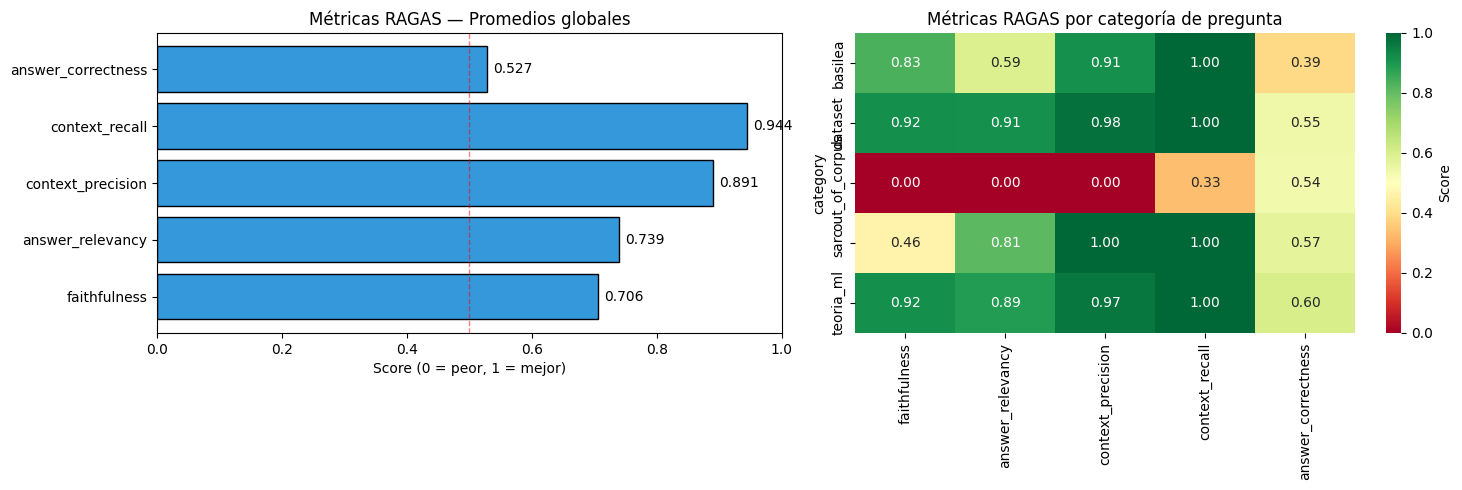

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Promedios globales
ax = axes[0]
promedios = [ragas_df[m].mean() for m in cols_metricas]
ax.barh(cols_metricas, promedios, color="#3498db", edgecolor="black")
ax.set_xlim(0, 1)
ax.set_xlabel("Score (0 = peor, 1 = mejor)")
ax.set_title("Métricas RAGAS — Promedios globales")
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.5)
for i, v in enumerate(promedios):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")

# Heatmap por categoría
ax = axes[1]
sns.heatmap(por_cat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "Score"}, ax=ax)
ax.set_title("Métricas RAGAS por categoría de pregunta")

plt.tight_layout()
plt.show()